# Initialize NMRlipids databank

In [1]:
from DatabankLib.protein_functions import *
import yaml

#databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"



# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()


/home/sosamuli/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPsimBank/Data/Simulations


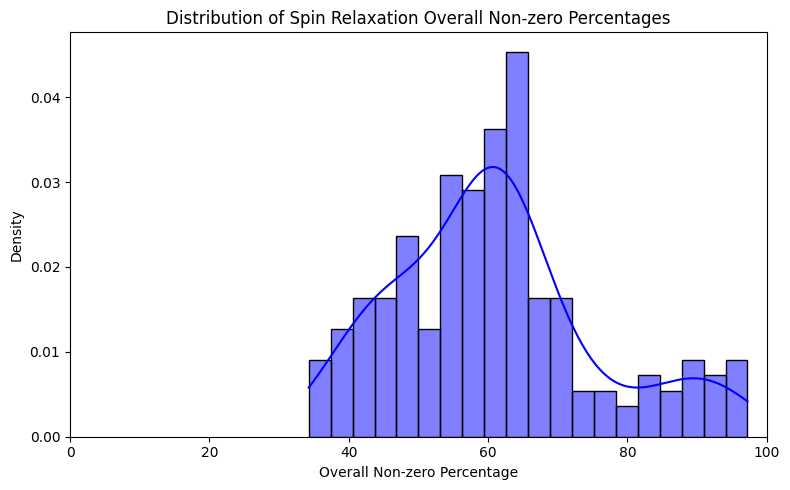

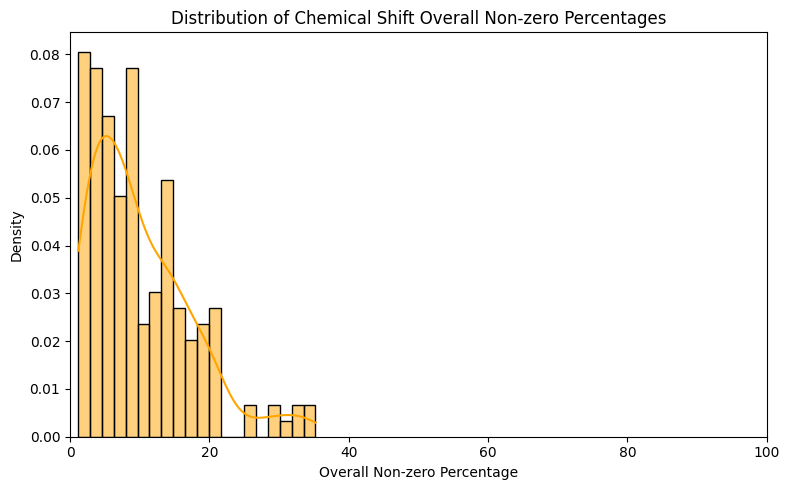

In [17]:
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

spin_overall = []
shift_overall = []

for system in systems:
    dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'

    spin_file = dataFolder + 'spin_relaxation_res_quality.yaml'
    shift_file = dataFolder + 'chemical_shift_res_quality.yaml'

    # Load spin relaxation overall percentage
    try:
        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in spin_data:
            spin_overall.append(spin_data['overall_non_zero_percentage'])
    except FileNotFoundError:
        print(f"Warning: {spin_file} not found")

    # Load chemical shift overall percentage
    try:
        with open(shift_file, 'r') as f:
            shift_data = yaml.safe_load(f)
        if 'overall_non_zero_percentage' in shift_data:
            shift_overall.append(shift_data['overall_non_zero_percentage'])
    except FileNotFoundError:
        print(f"Warning: {shift_file} not found")

# Plot spin relaxation overall percentages
plt.figure(figsize=(8, 5))
sns.histplot(spin_overall, color='blue', kde=True, stat='density', bins=20)
plt.xlabel('Overall Non-zero Percentage')
plt.ylabel('Density')
plt.title('Distribution of Spin Relaxation Overall Non-zero Percentages')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Plot chemical shift overall percentages
plt.figure(figsize=(8, 5))
sns.histplot(shift_overall, color='orange', kde=True, stat='density', bins=20)
plt.xlabel('Overall Non-zero Percentage')
plt.ylabel('Density')
plt.title('Distribution of Chemical Shift Overall Non-zero Percentages')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()



Spin relaxation: average non-zero percentage over all residues
  AMBER99SBWS:  55.88 %
  AMBER99SB-DISP:  64.18 %
  DESAMBER  :  65.55 %
  AMBER03WS :  59.82 %
  CHARMM    :  63.93 %


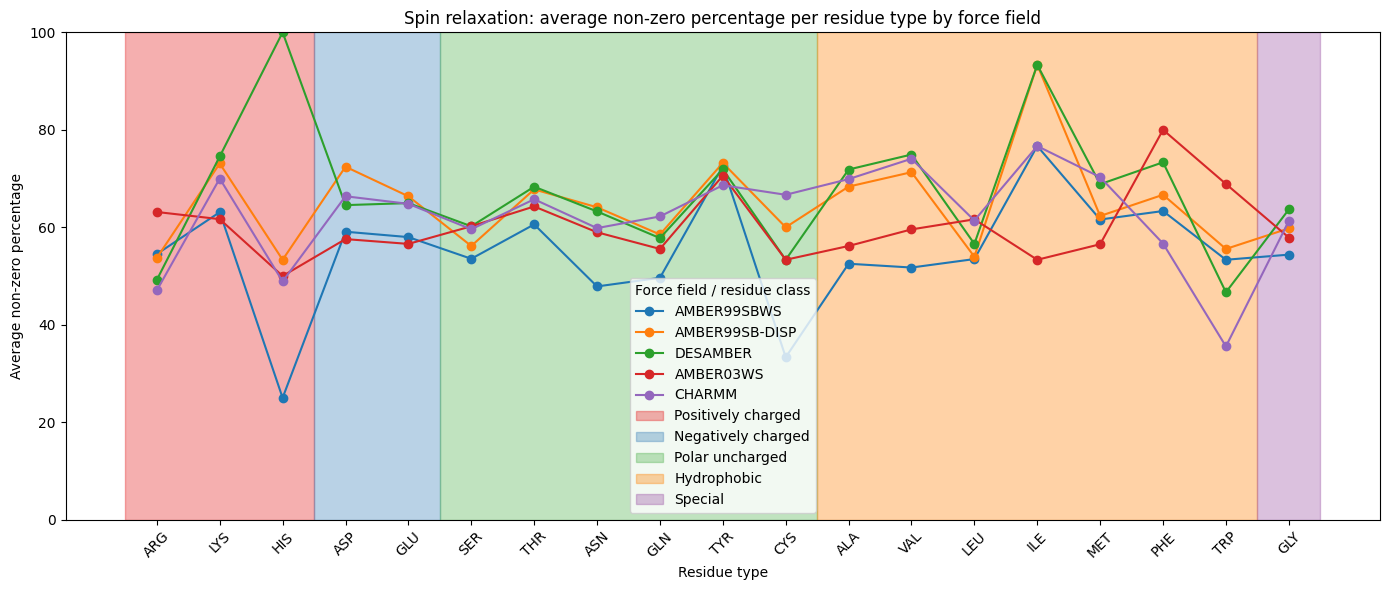


Chemical shift: average non-zero percentage over all residues
  AMBER99SBWS:  12.56 %
  AMBER99SB-DISP:   9.65 %
  DESAMBER  :  12.72 %
  AMBER03WS :   9.41 %
  CHARMM    :  13.04 %


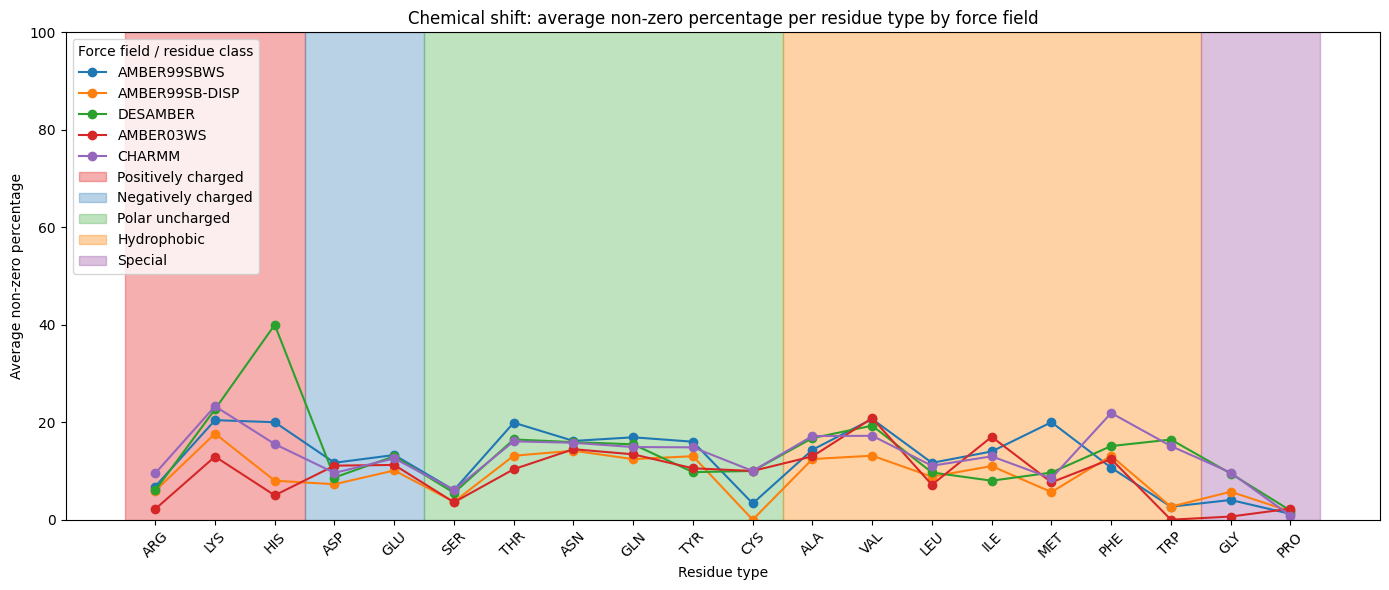

In [27]:
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict
import re

databankPath = '/home/sosamuli/work/NMRlipids/IDPsimBank/'

QUALITY_FILES = {
    "Spin relaxation": "spin_relaxation_res_quality.yaml",
    "Chemical shift": "chemical_shift_res_quality.yaml",
}

SKIP_KEYS = {
    "Averages",
    "overall_non_zero_percentage",
    "overall_percentage",
}

def extract_force_field(system):
    try:
        trj_file = system['TRJ'][0][0]
    except (IndexError, TypeError):
        return "UNKNOWN"

    match = re.search(r'_(DESAMBER|AMBER99SBWS|CHARMM|AMBER99SB-DISP|AMBER03WS)[^_]*_', trj_file, re.IGNORECASE)
    return match.group(1).upper() if match else "UNKNOWN"


def process_quality_file(filename, systems):
    """
    Returns:
      avg_residue_data[force_field][residue_type] = average percentage
      ff_overall_averages[force_field] = average over all residues
    """
    residue_data = defaultdict(lambda: defaultdict(list))

    for system in systems:
        dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'
        force_field = extract_force_field(system)
        file_path = dataFolder + filename

        try:
            with open(file_path, 'r') as f:
                data = yaml.safe_load(f)
        except FileNotFoundError:
            continue

        for residue_key, info in data.items():

            if residue_key in SKIP_KEYS:
                continue

            if not (isinstance(info, dict) and 'non_zero_percentage' in info):
                continue

            match = re.search(r'[A-Z]+$', residue_key)
            if not match:
                continue

            residue_type = match.group(0)
            residue_data[force_field][residue_type].append(
                info['non_zero_percentage']
            )

    avg_residue_data = defaultdict(dict)
    ff_overall_averages = {}

    for ff, residues in residue_data.items():
        all_vals = []

        for res_type, vals in residues.items():
            avg_residue_data[ff][res_type] = sum(vals) / len(vals)
            all_vals.extend(vals)

        ff_overall_averages[ff] = sum(all_vals) / len(all_vals) if all_vals else 0.0

    return avg_residue_data, ff_overall_averages

# Amino-acid classification (standard biophysical grouping)
AA_CLASSES = {
    "Positively charged": ["ARG", "LYS", "HIS"],
    "Negatively charged": ["ASP", "GLU"],
    "Polar uncharged": ["SER", "THR", "ASN", "GLN", "TYR", "CYS"],
    "Hydrophobic": ["ALA", "VAL", "LEU", "ILE", "MET", "PHE", "TRP"],
    "Special": ["GLY", "PRO"],
}

# Ordered list of residue types for x-axis
ORDERED_RESIDUES = [aa for group in AA_CLASSES.values() for aa in group]


AA_CLASS_COLORS = {
    "Positively charged": "#e41a1c",  # strong red
    "Negatively charged": "#377eb8",  # strong blue
    "Polar uncharged": "#4daf4a",     # strong green
    "Hydrophobic": "#ff7f00",         # orange
    "Special": "#984ea3",             # purple
}



def plot_quality(avg_residue_data, title):
    plt.figure(figsize=(14, 6))

    # Keep only residues that actually exist in data
    residue_types = [
        aa for aa in ORDERED_RESIDUES
        if any(aa in residues for residues in avg_residue_data.values())
    ]

    x_positions = range(len(residue_types))

    # Plot force fields
    for ff, residues in avg_residue_data.items():
        values = [residues.get(res, 0.0) for res in residue_types]
        plt.plot(x_positions, values, marker='o', label=ff)

    # Background shading by residue class
    start = 0
    for cls, aas in AA_CLASSES.items():
        cls_residues = [aa for aa in aas if aa in residue_types]
        if not cls_residues:
            continue

        end = start + len(cls_residues)
        plt.axvspan(
            start - 0.5,
            end - 0.5,
            color=AA_CLASS_COLORS[cls],
            alpha=0.35,
            label=cls
        )
        start = end

    # Axis formatting
    plt.xticks(x_positions, residue_types, rotation=45)
    plt.xlabel("Residue type")
    plt.ylabel("Average non-zero percentage")
    plt.title(title)
    plt.ylim(0, 100)

    # De-duplicate legend entries
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys(), title="Force field / residue class")

    plt.tight_layout()
    plt.show()

    
    

# ---- Run everything ----

for label, filename in QUALITY_FILES.items():
    avg_residue_data, ff_overall_averages = process_quality_file(filename, systems)

    print(f"\n{label}: average non-zero percentage over all residues")
    for ff, avg in ff_overall_averages.items():
        print(f"  {ff:10s}: {avg:6.2f} %")

    plot_quality(
        avg_residue_data,
        f"{label}: average non-zero percentage per residue type by force field"
    )


In [18]:
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re

# Example paths
databankPath = '/home/sosamuli/work/NMRlipids/IDPsimBank/'

# Dictionary to store data: {force_field: {residue_type: [percentages]}}
residue_data = defaultdict(lambda: defaultdict(list))

for system in systems:
    dataFolder = databankPath + 'Data/Simulations/' + system['path'] + '/'
    
    # Extract force field from TRJ filename
    trj_file = system['TRJ'][0][0]  # [['filename']]
    # Example filename: aSyn_replica_03_AMBER99SBWS_2000ns.xtc
    match = re.search(r'_(AMBER|CHARMM|OPLS|GROMOS)[^_]*_', trj_file, re.IGNORECASE)
    if match:
        force_field = match.group(1).upper()
    else:
        force_field = "UNKNOWN"

    # Load spin relaxation YAML (or chemical shift, adjust if needed)
    spin_file = dataFolder + 'spin_relaxation_res_quality.yaml'
    try:
        with open(spin_file, 'r') as f:
            spin_data = yaml.safe_load(f)
        for residue_key, info in spin_data.items():
            if isinstance(info, dict) and 'non_zero_percentage' in info:
                # Extract residue type from residue key (e.g., 101GLY -> GLY)
                residue_type = re.findall(r'[A-Z]+$', residue_key)[0]
                residue_data[force_field][residue_type].append(info['non_zero_percentage'])
    except FileNotFoundError:
        print(f"Warning: {spin_file} not found")

# Compute average percentages per residue type and force field
avg_data = defaultdict(dict)
for ff, residues in residue_data.items():
    for res_type, percentages in residues.items():
        avg_data[ff][res_type] = sum(percentages) / len(percentages)

# Plotting
plt.figure(figsize=(12, 6))
res_types_sorted = sorted({res for residues in avg_data.values() for res in residues})

for ff, residues in avg_data.items():
    values = [residues.get(res, 0) for res in res_types_sorted]
    plt.plot(res_types_sorted, values, marker='o', label=ff)

plt.xlabel('Residue Type')
plt.ylabel('Average Non-zero Percentage')
plt.title('Average Non-zero Percentage per Residue Type by Force Field')
plt.ylim(0, 100)
plt.legend(title='Force Field')
plt.tight_layout()
plt.show()


IndexError: list index out of range

# Show ranking of simulations based on total quality, tail quality and headgroup quality

In [4]:
Fragments = ['total','tails','headgroup','FormFactor']

for SortBasedOn in Fragments:
    #print(SortBasedOn)

    print('Sorted based on ', SortBasedOn, ' quality')
    
    FFrankingPath = os.path.join(NMLDB_DATA_PATH, 'Ranking' ,'SYSTEM_' + SortBasedOn + '_Ranking.json')
    
    with open(FFrankingPath) as json_file:
        FFranking = json.load(json_file)
    
    jpyroutines.showTable(FFranking,'TotalQuality')

Sorted based on  total  quality


**FAILURE:** no FF defined for the system

'c04/cdb/c04cdb61143bb72ba2ddee11599e6bbfaf6cb211/a31f42800216d84d2242eae2af8ac2cbd6b033ee/'

**FAILURE:** no FF defined for the system

'a7f/9f3/a7f9f36feaa77791483dadb0157f86a6a519f2c3/a30f01e8771c44dc59b78753d1dd27ca67920e38/'

...

**FAILURE:** no FF defined for the system

'c04/cdb/c04cdb61143bb72ba2ddee11599e6bbfaf6cb211/a31f42800216d84d2242eae2af8ac2cbd6b033ee/'

**FAILURE:** no FF defined for the system

'a7f/9f3/a7f9f36feaa77791483dadb0157f86a6a519f2c3/a30f01e8771c44dc59b78753d1dd27ca67920e38/'

,FFQuality,Forcefield,Molecules,Number of molecules,Temperature,ID,headgroup,tails,total
0,0.02,Lipid14,POPC:SOL,(72:2234),303.00,154,NaN,NaN,NaN
1,0.07,ECC-lipids,POPC:SOL,(128:6400),313.00,360,NaN,NaN,NaN
2,0.07,Lipid17,POPC:SOL:CHOL,(64:4000:16),298.15,662,NaN,NaN,NaN
3,0.08,Slipids,POPC:SOL,(122:4880),303.00,376,NaN,NaN,NaN
4,0.10,Poger GROMOS 53A6_L,DPPC:SOL,(128:5841),323.00,365,NaN,NaN,NaN
5,0.10,Poger GROMOS 53A6_L,DPPC:SOL,(128:5841),323.00,593,NaN,NaN,NaN
6,0.10,Slipids,POPE:SOL,(500:25000),310.00,414,0.01,0.78,0.52
7,0.13,ECC-lipids,POPC:SOL,(128:6400),313.00,103,NaN,NaN,NaN
8,0.14,Lipid17,POPC:SOL,(64:3200),298.15,715,0.49,0.73,0.65
9,0.15,OPLS3e,POPC:SOL,(200:8859),300.00,805,0.73,0.84,0.81


# Show ranking separately for each lipid based on total, sn-1, sn-2, or headgroup quality

In [10]:
from DatabankLib.settings.molecules import Lipid


Fragments = ['total','sn-1','sn-2','headgroup']

for SortBasedOn in Fragments:
    for lipid in lipids_set:
        print('Quality of',SortBasedOn,' of ', lipid.name)
        FFrankingPath = os.path.join(NMLDB_DATA_PATH, 'Ranking' , lipid.name + '_' + SortBasedOn + '_Ranking.json')
    
        try:
            with open(FFrankingPath) as json_file:
                FFranking = json.load(json_file)
        except:
            print('File not found')
            continue
            
        jpyroutines.showTable(FFranking, lipid.name)

Quality of total  of  SLiPC
File not found
Quality of total  of  PYPC
File not found
Quality of total  of  POPI
File not found
Quality of total  of  SM18
File not found
Quality of total  of  DHMDMAB
File not found
Quality of total  of  SLPI
File not found
Quality of total  of  CER
File not found
Quality of total  of  CHOL


,headgroup,tail,total,Forcefield,Molecules,Number of molecules,Temperature,ID
0,NaN,0.235516,0.24,slipids,CHOL:POPC:SOL,(256:256:20334),298,82
1,NaN,0.170506,0.17,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(64:64:10314),298,299


Quality of total  of  TOCL
File not found
Quality of total  of  DMPC


,sn-1,sn-2,headgroup,total,Forcefield,Molecules,Number of molecules,Temperature,ID
0,0.84,0.45,0.69,0.66,CHARMM36,DMPC:SOL,(200:1000),314.00,800
1,0.89,0.41,0.65,0.65,CHARMM36,DMPC:SOL,(200:2000),314.00,809
2,0.30,0.80,0.78,0.63,OPLS4,DMPC:SOL,(200:2000),314.00,810
3,0.38,0.80,0.69,0.62,OPLS4,DMPC:SOL,(200:1000),314.00,811
4,0.74,0.45,0.66,0.62,OPLS4,DMPC:SOL,(200:9000),314.00,813
5,0.14,0.10,0.66,0.30,CHARMM36,DMPC:SOL,(200:10000),314.00,808
6,0.13,0.13,0.63,0.30,Charmm36,DMPC:SOL,(64:3200),313.15,789
7,0.13,0.15,0.60,0.29,Charmm36,DMPC:SOL,(64:3200),313.15,788


Quality of total  of  POPC


...

Quality of headgroup  of  DPPC
File not found
Quality of headgroup  of  BOG
File not found
Quality of headgroup  of  DRPC
File not found
Quality of headgroup  of  POPS


,sn-1,sn-2,headgroup,total,Forcefield,Molecules,Number of molecules,Temperature,ID
0,0.11,0.14,0.26,0.17,CHARMM36-UA,POPS:SOL:SOD,(128:4480:128),298,263
1,0.06,0.08,0.26,0.13,CHARMM36,POPS:SOL:SOD,(128:4480:128),298,5
2,0.07,0.10,0.22,0.13,CHARMM36-UA,POPS:SOL:SOD,(128:4480:128),298,367
3,0.63,0.47,0.21,0.44,"GROMOS-CKP, Berger/Chiu NH3 charges and PME",POPS:SOL:SOD,(128:4480:128),298,597
4,0.35,0.43,0.20,0.33,"GROMOS-CKP, Berger/Chiu NH3 charges and PME",POPS:SOL:SOD,(128:4480:128),298,535
5,0.07,0.08,0.19,0.11,MacRog,POPS:SOL:SOD,(128:4480:128),298,292
6,0.01,0.06,0.18,0.08,CHARMM36,POPS:SOL:SOD,(128:4480:128),298,106
7,0.08,0.06,0.17,0.10,MacRog,POPS:SOL:SOD,(128:4480:128),298,26
8,0.64,0.69,0.16,0.50,"ECC-lipids, SPC water model, ECC-ions",POPS:SOL:SOD,(72:3600:72),298,443
9,0.56,0.53,0.15,0.41,"GROMOS-CKP, GROMOS NH3 charges and PME",POPS:SOL:SOD,(128:4480:128),298,425


Quality of headgroup  of  DOG
File not found
Quality of headgroup  of  PAzePCdeprot
File not found
Quality of headgroup  of  DPPGK
File not found
Quality of headgroup  of  DDOPC
File not found
Quality of headgroup  of  SAPI25
File not found
Quality of headgroup  of  TMCL
File not found
Quality of headgroup  of  SAPI
File not found
Quality of headgroup  of  DEPC
File not found
Quality of headgroup  of  POPG


,sn-1,sn-2,headgroup,total,Forcefield,Molecules,Number of molecules,Temperature,ID
0,0.1,0.48,0.12,0.23,Slipids,POPG:SOL:SOD,(288:10664:288),298,207


Quality of headgroup  of  SAPI24
File not found
Quality of headgroup  of  DLPC
File not found
Quality of headgroup  of  GB3
File not found
Quality of headgroup  of  DLIPC
File not found


# Show form factor ranking only for systems with a specific lipid (cholesterol as an example)

In [8]:
### This is showing the ranking only for systems containing cholesterol

FFrankingPath = os.path.join(NMLDB_DATA_PATH, 'Ranking' , 'SYSTEM_FormFactor_Ranking.json')
lipid = 'CHOL'

with open(FFrankingPath) as json_file:
    FFranking = json.load(json_file)

NewRank = []
for i in FFranking:
    if lipid in i['system']['COMPOSITION']:
        NewRank.append(i)
   
jpyroutines.showTable(NewRank,'TotalQuality')

,FFQuality,Forcefield,Molecules,Number of molecules,Temperature,ID,headgroup,tails,total
0,0.07,Lipid17,POPC:SOL:CHOL,(64:4000:16),298.15,662,NaN,NaN,NaN
1,0.17,Lipid17,POPC:SOL:CHOL,(1024:64000:256),298.15,667,NaN,NaN,NaN
2,0.17,Lipid17,POPC:SOL:CHOL,(256:16000:64),298.15,666,NaN,NaN,NaN
3,0.23,MacRog,POPC:SOL:CHOL,(1024:64000:256),298.15,677,NaN,NaN,NaN
4,0.23,MacRog,POPC:SOL:CHOL,(256:16000:64),298.15,706,NaN,NaN,NaN
5,0.26,Lipid17,POPC:SOL:CHOL,(64:3600:8),298.15,680,NaN,NaN,NaN
6,0.26,MacRog,POPC:SOL:CHOL,(64:3600:8),298.15,665,NaN,NaN,NaN
7,0.27,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(110:18:8481),298.00,589,0.02,0.40,0.27
8,0.33,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(84:44:6794),298.00,206,0.04,0.07,0.06
9,0.36,MacRog,POPC:SOL:CHOL,(1024:57600:128),298.15,660,NaN,NaN,NaN


# Show sn-1 ranking only for systems with POPC and CHOLESTEROL

In [9]:
### This is showing the ranking only for systems containing POPC and cholesterol

FFrankingPath = os.path.join(NMLDB_DATA_PATH, 'Ranking', 'POPC_sn-1_Ranking.json')
lipid = 'CHOL'


with open(FFrankingPath) as json_file:
    FFranking = json.load(json_file)

NewRank = []

for i in FFranking:
    #print(i)
    #for tst in i:
    #    print(tst)
    if lipid in i['system']['COMPOSITION']:
        NewRank.append(i)
   
jpyroutines.showTable(NewRank,'POPC')


,sn-1,sn-2,headgroup,total,Forcefield,Molecules,Number of molecules,Temperature,ID
0,0.82,0.50,0.03,0.45,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(120:8:7290),298,305
1,0.60,0.49,0.71,0.60,slipids,CHOL:POPC:SOL,(256:256:20334),298,82
2,0.37,0.71,0.03,0.37,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(110:18:8481),298,589
3,0.17,0.24,0.07,0.16,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(64:64:10314),298,299
4,0.12,0.18,0.08,0.13,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(50:78:5782),298,15
5,0.08,0.26,0.10,0.15,Berger and Modified Höltje model for cholesterol,POPC:CHOL:SOL,(84:44:6794),298,206
